<a href="https://colab.research.google.com/github/Infoanirban12/Task-7---Basic-Sales-Summary-using-SQLite-and-Python/blob/main/Basic_Sales_Summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sales Summary:
   product  total_qty  revenue
0   Apple         90    225.0
1  Banana        150    180.0
2  Orange         90    162.0


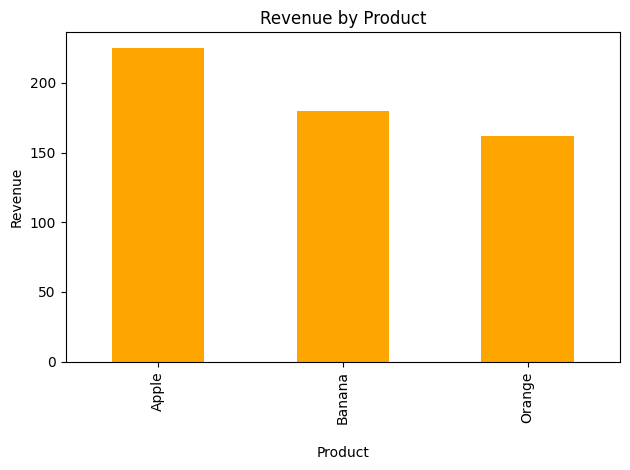

In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect("/content/sales_data.db")
cursor = conn.cursor()

# Create the sales table
cursor.execute('''
CREATE TABLE IF NOT EXISTS sales (
    product TEXT,
    quantity INTEGER,
    price REAL
 )
''')

# Insert sample data
sample_data = [
    ("Apple", 10, 2.5),
    ("Banana", 15, 1.2),
    ("Orange", 8, 1.8),
    ("Apple", 5, 2.5),
    ("Banana", 10, 1.2),
    ("Orange", 7, 1.8),
  ]
cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()

# Run SQL query to get total quantity and revenue per product
query = '''
SELECT
    product,
    SUM(quantity) AS total_qty,
    SUM(quantity * price) AS revenue
    FROM sales GROUP BY product
'''

df = pd.read_sql_query(query, conn)

# Display results
print("Sales Summary:\n", df)

# Plot bar chart for revenue
df.plot(kind='bar', x='product', y='revenue', color='orange', legend=False)
plt.title('Revenue by Product')
plt.xlabel('\nProduct')
plt.ylabel('Revenue')
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()


